# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

## Plano do projeto

Fazer uma verificação dos dados para garantir que estão todos adequados, sem dados faltantes, duplicados, etc. Em seguida fazer uma analise dos dados e testar a hipotese de qual plano gera maior receita para empresa.

## Inicialização

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from math import factorial
from scipy import stats as st

## Carregue os dados

In [3]:
calls_df = pd.read_csv('/datasets/megaline_calls.csv')
internet_df = pd.read_csv('/datasets/megaline_internet.csv')
messages_df = pd.read_csv('/datasets/megaline_messages.csv')
plans_df = pd.read_csv('/datasets/megaline_plans.csv')
users_df = pd.read_csv('/datasets/megaline_users.csv')

## Prepare os dados

[Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.]

## Planos

In [4]:
print(plans_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [5]:
print(plans_df.sample(2))

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


- o tipo de dados das colunas usd_monthly_pay e usd_per_gb pode ser mudado de int pra float para abranger valores não inteiros.
- a quantidade de internet usada por mês (mb_per_month_included) e o preço cobrado (usd_per_gb) estão incopatíveis entre eles, deve ser corrigido convertendo a internet usada de mb para gb.

## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [6]:
plans_df['usd_monthly_pay'] = plans_df['usd_monthly_pay'].astype(float)
plans_df['usd_per_gb'] = plans_df['usd_per_gb'].astype(float)

## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [7]:
plans_df['gb_per_month_included'] = plans_df['mb_per_month_included']/1024

## Usuários

In [8]:
print(users_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [9]:
print(users_df.sample(5))

     user_id first_name last_name  age  \
17      1017      Boris     Gates   61   
238     1238  Jackeline      Byrd   42   
288     1288    Jenette      Rush   60   
269     1269     Irving  Thompson   39   
94      1094     Walter  Petersen   54   

                                                 city    reg_date      plan  \
17   Washington-Arlington-Alexandria, DC-VA-MD-WV MSA  2018-08-26      surf   
238               Dallas-Fort Worth-Arlington, TX MSA  2018-06-16      surf   
288              Las Vegas-Henderson-Paradise, NV MSA  2018-07-18      surf   
269               Dallas-Fort Worth-Arlington, TX MSA  2018-09-13  ultimate   
94             Los Angeles-Long Beach-Anaheim, CA MSA  2018-10-30      surf   

     churn_date  
17          NaN  
238         NaN  
288         NaN  
269  2018-12-15  
94   2018-12-12  


- O tipo de dados da data de registro e de cancelamento esta como object e queremos que esteja como datetime.
- As datas podem ser separadas por mes para eventual analise.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [10]:
users_df['reg_date'] = pd.to_datetime(users_df['reg_date'])
users_df['churn_date'] = pd.to_datetime(users_df['churn_date'])

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [11]:
users_df['reg_month'] = users_df['reg_date'].dt.month
users_df['churn_month'] = users_df['churn_date'].dt.month

## Chamadas

In [12]:
print(calls_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [13]:
print(calls_df.sample(5))

              id  user_id   call_date  duration
9726    1043_282     1043  2018-11-27      7.33
2147    1009_569     1009  2018-08-14      3.31
57652    1208_34     1208  2018-12-28     14.03
127846  1458_194     1458  2018-08-30      6.41
1290    1007_311     1007  2018-09-09      0.00


- A coluna de data da ligação (call_date) esta com o tipo de dados object, precisamos mudar para datetime.
- As datas podem ser separadas por mes para eventual analise.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [14]:
calls_df['call_date'] = pd.to_datetime(calls_df['call_date'])

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [15]:
calls_df['month'] = calls_df['call_date'].dt.month

## Mensagens

In [16]:
print(messages_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [17]:
print(messages_df.sample(5))

             id  user_id message_date
17888   1118_66     1118   2018-12-25
41289  1264_483     1264   2018-05-28
5429   1052_186     1052   2018-12-03
5602    1053_89     1053   2018-08-24
48730  1326_267     1326   2018-11-15


- A coluna de data da mensagem (message_date) esta com o tipo de dados object, precisamos mudar para datetime.
- As datas podem ser separadas por mes para eventual analise.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [18]:
messages_df['message_date'] = pd.to_datetime(messages_df['message_date'])

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [19]:
messages_df['month'] = messages_df['message_date'].dt.month

## Internet

In [20]:
print(internet_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [21]:
print(internet_df.sample(5))

              id  user_id session_date  mb_used
66751   1311_607     1311   2018-08-22     0.00
102642   1491_99     1491   2018-05-21   493.18
13792   1064_240     1064   2018-07-08   168.19
20166   1090_407     1090   2018-11-14     0.00
89867   1414_323     1414   2018-09-30   102.21


- A coluna de data da sessão (session_date) esta com o tipo de dados object, precisamos mudar para datetime.
- As datas podem ser separadas por mes para eventual analise.
- A coluna de internet usada esta em mb, podemos converter ela para gb para padronizar nossos dados.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [22]:
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'])

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [23]:
internet_df['month'] = internet_df['session_date'].dt.month
internet_df['gb_used'] = internet_df['mb_used']/1024

## Estude as condições dos planos

- O plano surf é mais focado em internet, com poucas mensagens e tempo de ligação incluso comparado ao ultimate que tem bem mais desses dois, mas não tanta internet a mais, e tambem é cobrado diferente quando um beneficio é usado alem do que o plano cobre (surf cobra mais, ultimate cobra menos)

In [24]:
plans_df.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30.0


## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [25]:
calls_per_user = calls_df.groupby(['user_id','month'])['id'].count().reset_index(name='cnt_calls')
calls_per_user.head()

,user_id,month,cnt_calls
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [26]:
duration_per_user = calls_df.groupby(['user_id','month'])['duration'].sum().reset_index(name='sum_calls')
duration_per_user.head()

,user_id,month,sum_calls
0,1000,12,116.83
1,1001,8,171.14
2,1001,9,297.69
3,1001,10,374.11
4,1001,11,404.59


In [27]:
messages_per_user = messages_df.groupby(['user_id','month'])['id'].count().reset_index(name='cnt_messages')
messages_per_user.head()

,user_id,month,cnt_messages
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [28]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
traffic_per_user = internet_df.groupby(['user_id','month'])['gb_used'].sum().reset_index(name='sum_gb')
traffic_per_user.head()

,user_id,month,sum_gb
0,1000,12,1.856904
1,1001,8,6.756982
2,1001,9,13.002754
3,1001,10,21.807119
4,1001,11,18.070605


[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

In [29]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
df_merged = pd.merge(traffic_per_user,messages_per_user,on=['user_id','month'], how= 'outer')
df_merged = pd.merge(df_merged,calls_per_user,on=['user_id','month'], how= 'outer')
df_merged = pd.merge(df_merged,duration_per_user,on=['user_id','month'], how= 'outer')

df_merged.fillna(0.0, inplace=True)

df_merged.head()

,user_id,month,sum_gb,cnt_messages,cnt_calls,sum_calls
0,1000,12,1.856904,11.0,16.0,116.83
1,1001,8,6.756982,30.0,27.0,171.14
2,1001,9,13.002754,44.0,49.0,297.69
3,1001,10,21.807119,53.0,65.0,374.11
4,1001,11,18.070605,36.0,64.0,404.59


In [30]:
# Adicione as informações sobre o plano
df_merged = pd.merge(df_merged,users_df.drop(columns=['reg_date']), on='user_id', how='left')
df_merged = pd.merge(df_merged,plans_df, left_on='plan', right_on='plan_name', how='left')  
df_merged.head()

,user_id,month,sum_gb,cnt_messages,cnt_calls,sum_calls,first_name,last_name,age,city,...,churn_month,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,1000,12,1.856904,11.0,16.0,116.83,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",...,NaN,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30.0
1,1001,8,6.756982,30.0,27.0,171.14,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,NaN,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0
2,1001,9,13.002754,44.0,49.0,297.69,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,NaN,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0
3,1001,10,21.807119,53.0,65.0,374.11,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,NaN,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0
4,1001,11,18.070605,36.0,64.0,404.59,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,NaN,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0


[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [51]:
df_merged.sample(5)

,user_id,month,sum_gb,cnt_messages,cnt_calls,sum_calls,first_name,last_name,age,city,...,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included,receita
711,1149,12,7.726553,0.0,55.0,399.71,Jamaal,Camacho,54,"San Francisco-Oakland-Berkeley, CA MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0,20.00
834,1174,5,4.729365,16.0,26.0,167.60,Larisa,Ellis,67,"Cleveland-Elyria, OH MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0,20.00
1589,1346,6,18.903828,54.0,41.0,284.82,Emmie,Gonzalez,59,"Tucson, AZ MSA",...,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30.0,70.00
215,1052,11,4.541406,52.0,27.0,197.32,Edmond,Hopkins,47,"Houston-The Woodlands-Sugar Land, TX MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0,20.06
1636,1356,12,19.750986,37.0,31.0,211.39,Hae,Ryan,46,"Milwaukee-Waukesha, WI MSA",...,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0,70.00


In [32]:
# Calcule a receita mensal para cada usuário
def receita(data):
    receita = data['usd_monthly_pay']
    if data['sum_gb'] > data['gb_per_month_included']:
        receita += np.ceil(data['sum_gb']-data['gb_per_month_included'])*data['usd_per_gb']

    if data['sum_calls'] > data['minutes_included']:
        receita += np.ceil(data['sum_calls']-data['minutes_included'])*data['usd_per_minute']

    if data['cnt_messages'] > data['messages_included']:
        receita += np.ceil(data['cnt_messages']-data['messages_included'])*data['usd_per_message']
    return receita


df_merged['receita'] = df_merged.apply(receita, axis=1)
df_merged[['user_id','receita']].head()

,user_id,receita
0,1000,70.00
1,1001,20.00
2,1001,20.00
3,1001,90.09
4,1001,60.00


## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

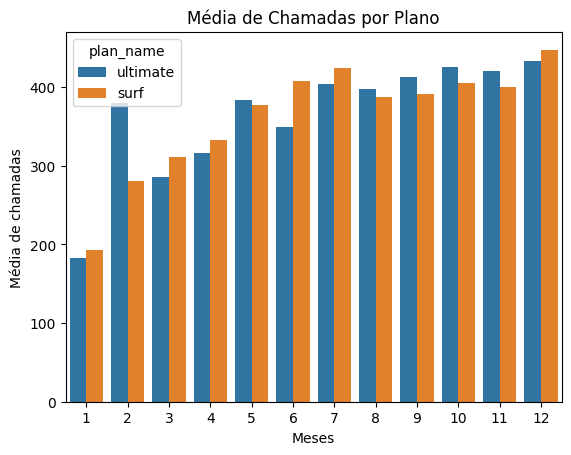

In [33]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.
sns.barplot(data=df_merged,y='sum_calls',x='month',hue='plan_name',ci=None)
plt.xlabel('Meses')
plt.ylabel('Média de chamadas')
plt.title('Média de Chamadas por Plano')
plt.show()

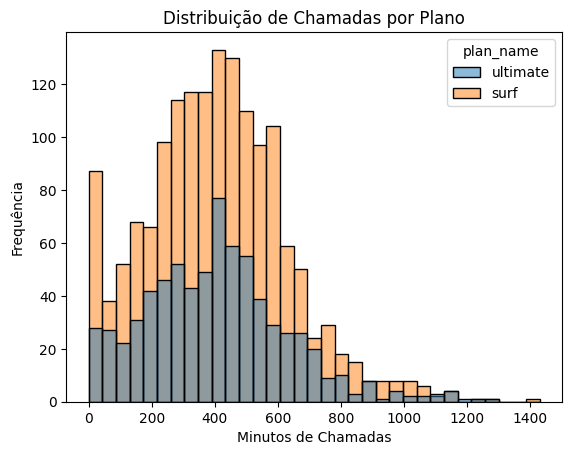

In [34]:
sns.histplot(data=df_merged,x='sum_calls',hue='plan_name')
plt.xlabel('Minutos de Chamadas')
plt.ylabel('Frequência')
plt.title('Distribuição de Chamadas por Plano')
plt.show()

[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [54]:
# Calcule a média e a variância da duração mensal das chamadas
df_merged.groupby(['plan_name','month'])['sum_calls'].agg({'mean','var','std'})

mean         std           var
plan_name month                                      
surf      1      192.840000  121.636508  14795.440200
          2      280.851111  216.700761  46959.219961
          3      310.970000  178.385308  31821.317991
          4      332.380000  213.578245  45615.666796
          5      377.053247  230.830939  53282.922217
          6      407.208866  201.887744  40758.661193
          7      424.523223  233.311346  54434.184064
          8      387.169630  220.490503  48616.061790
          9      390.992062  203.912959  41580.494645
          10     405.692363  216.174537  46731.430317
          11     399.599823  214.720949  46105.085924
          12     447.475283  238.711641  56983.247423
ultimate  1      183.162500  122.439250  14991.369958
          2      379.861429  261.802002  68540.288348
          3      285.701667  232.967631  54273.917252
          4      316.508095  176.232027  31057.727496
          5      383.664828  198.218594  39290.610940
          6      349.811064  194.739212  37923.360514
          7      403.767288  254.645689  64844.426958
          8      397.274789  218.357939  47680.189425
          9      413.287326  225.819630  50994.505514
          10     425.168019  219.934586  48371.222127
          11     420.477559  232.948820  54265.152604
          12     433.012583  236.181535  55781.717507

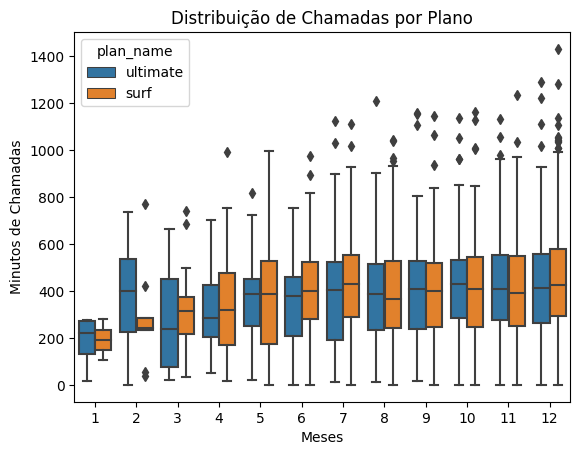

In [36]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
sns.boxplot(data=df_merged,hue='plan_name',x='month',y='sum_calls')
plt.xlabel('Meses')
plt.ylabel('Minutos de Chamadas')
plt.title('Distribuição de Chamadas por Plano')
plt.show()

- O comportamento dos usuários em termos de chamadas são se diferem muito em relação ao plano, em resumo, clientes de ambos os planos utilizam o mesmo tanto de chamadas.

### Mensagens

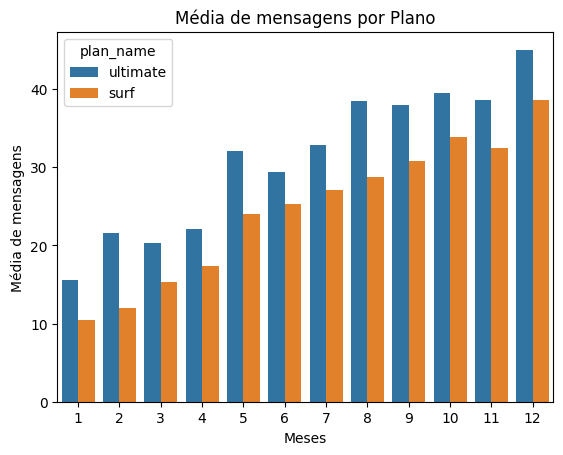

In [37]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
sns.barplot(data=df_merged,y='cnt_messages',x='month',hue='plan_name',ci=None)
plt.xlabel('Meses')
plt.ylabel('Média de mensagens')
plt.title('Média de mensagens por Plano')
plt.show()

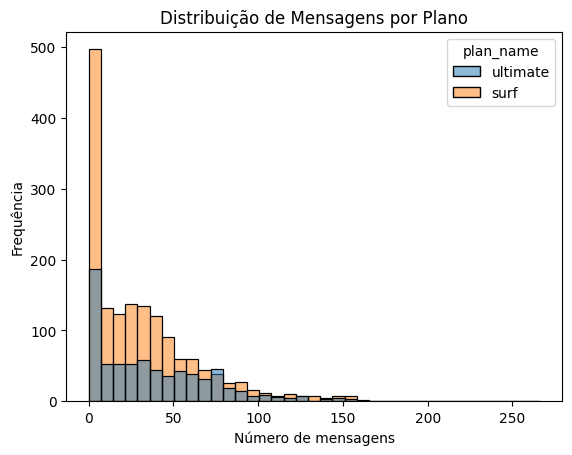

In [38]:
sns.histplot(data=df_merged,x='cnt_messages',hue='plan_name')
plt.xlabel('Número de mensagens')
plt.ylabel('Frequência')
plt.title('Distribuição de Mensagens por Plano')
plt.show()

In [56]:
df_merged.groupby(['plan_name','month'])['cnt_messages'].agg({'mean','var','std'})

mean        std          var
plan_name month                                   
surf      1      10.500000  14.849242   220.500000
          2      12.000000  19.646883   386.000000
          3      15.260870  18.616262   346.565217
          4      17.400000  22.396246   501.591837
          5      24.012987  29.106652   847.197198
          6      25.298969  30.247646   914.920103
          7      27.033058  30.395979   923.915565
          8      28.777778  32.086064  1029.515528
          9      30.762887  31.683268  1003.829496
          10     33.839662  35.713663  1275.465708
          11     32.385159  32.639608  1065.344034
          12     38.600629  38.185843  1458.158612
ultimate  1      15.500000  17.710637   313.666667
          2      21.571429  21.869744   478.285714
          3      20.250000  25.580977   654.386364
          4      22.047619  23.326972   544.147619
          5      32.103448  36.018195  1297.310345
          6      29.340426  29.285162   857.620722
          7      32.830508  30.991741   960.488019
          8      38.478873  34.588544  1196.367404
          9      37.895349  32.417871  1050.918331
          10     39.443396  34.944331  1221.106289
          11     38.606299  35.109389  1232.669166
          12     45.006623  39.362672  1549.419956

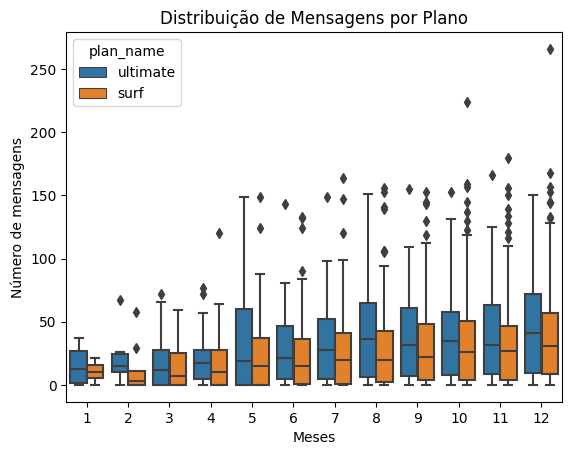

In [39]:
sns.boxplot(data=df_merged,hue='plan_name',x='month',y='cnt_messages')
plt.xlabel('Meses')
plt.ylabel('Número de mensagens')
plt.title('Distribuição de Mensagens por Plano')
plt.show()

- Não temos tanta difereça na distribuiçao de mensagens entre os planos mas a média do plano ultimate é um pouco mais alta. 
- Em outras palavras, usuários ultimate eviam em media mais mensagens, mas uma porção significativa de usuários surf enviam tanto quanto usuários ultimate. 

### Internet

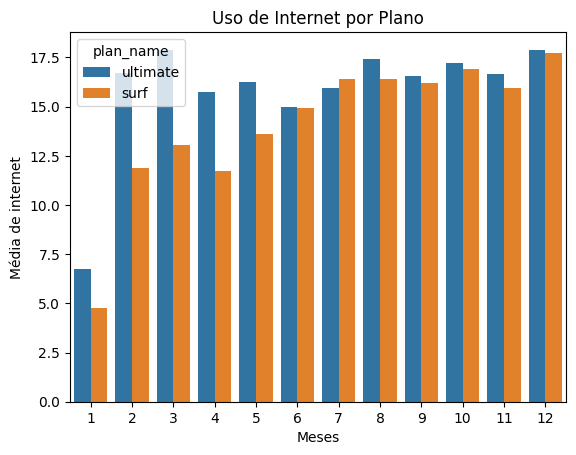

In [40]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
sns.barplot(data=df_merged,y='sum_gb',x='month',hue='plan_name',ci=None)
plt.xlabel('Meses')
plt.ylabel('Média de internet')
plt.title('Uso de Internet por Plano')
plt.show()

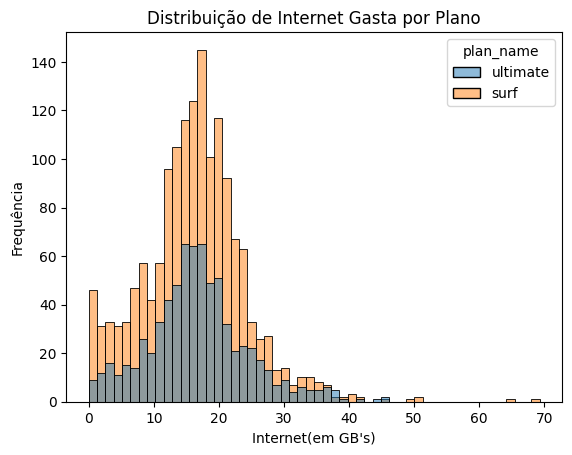

In [41]:
sns.histplot(data=df_merged,x='sum_gb',hue='plan_name')
plt.xlabel("Internet(em GB's)")
plt.ylabel('Frequência')
plt.title('Distribuição de Internet Gasta por Plano')
plt.show()

In [57]:
df_merged.groupby(['plan_name','month'])['sum_gb'].agg({'mean','var','std'})

mean        std         var
plan_name month                                  
surf      1       4.760605   4.170728   17.394976
          2      11.893402   6.453664   41.649779
          3      13.032656   8.067468   65.084035
          4      11.703323   7.503975   56.309643
          5      13.609722   7.656931   58.628592
          6      14.942900   6.845236   46.857252
          7      16.390235   7.854292   61.689899
          8      16.401691   8.436759   71.178902
          9      16.202570   6.995668   48.939371
          10     16.905601   7.722130   59.631291
          11     15.956303   7.384225   54.526776
          12     17.707490   8.294886   68.805130
ultimate  1       6.755950   3.954139   15.635216
          2      16.727352   5.992076   35.904976
          3      17.892108  11.568831  133.837858
          4      15.743803   9.183251   84.332091
          5      16.234846   7.359299   54.159275
          6      14.978439   8.287244   68.678409
          7      15.961664   8.077725   65.249644
          8      17.397188   7.592551   57.646831
          9      16.572138   6.859546   47.053374
          10     17.199759   7.372580   54.354932
          11     16.634458   7.410911   54.921606
          12     17.893742   7.682097   59.014608

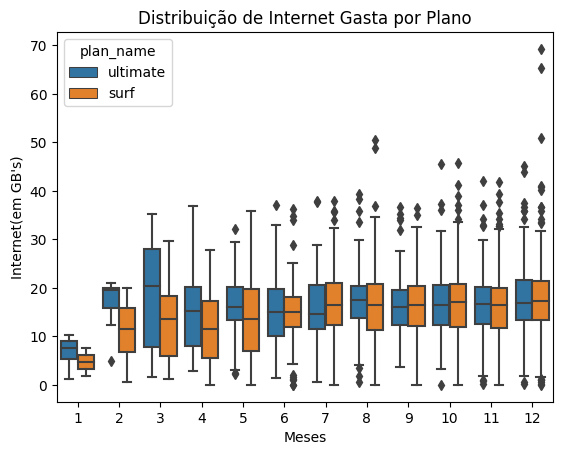

In [42]:
sns.boxplot(data=df_merged,hue='plan_name',x='month',y='sum_gb')
plt.xlabel('Meses')
plt.ylabel("Internet(em GB's)")
plt.title('Distribuição de Internet Gasta por Plano')
plt.show()

- Em geral, a média de uso de internet é um pouco maior para os usuários do plano ultimate, mas vemos que uma quantidade sigificatia de clientes surf utilizam o mesmo tanto que assinantes ultimate.

## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

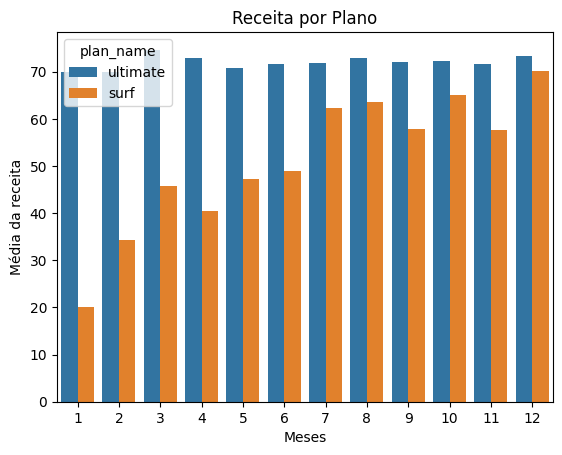

In [43]:
sns.barplot(data=df_merged,y='receita',x='month',hue='plan_name',ci=None)
plt.xlabel('Meses')
plt.ylabel('Média da receita')
plt.title('Receita por Plano')
plt.show()

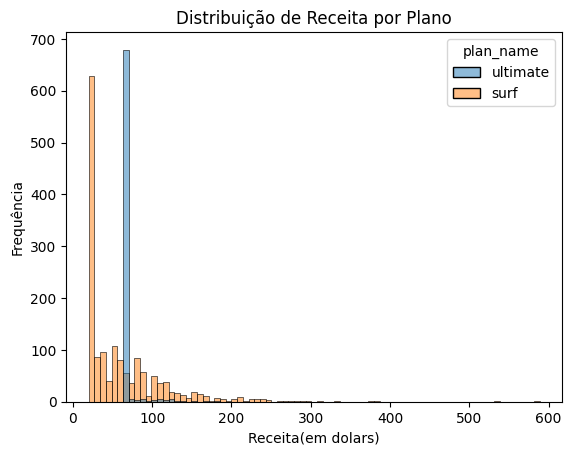

In [44]:
sns.histplot(data=df_merged,x='receita',hue='plan_name')
plt.xlabel("Receita(em dolars)")
plt.ylabel('Frequência')
plt.title('Distribuição de Receita por Plano')
plt.show()

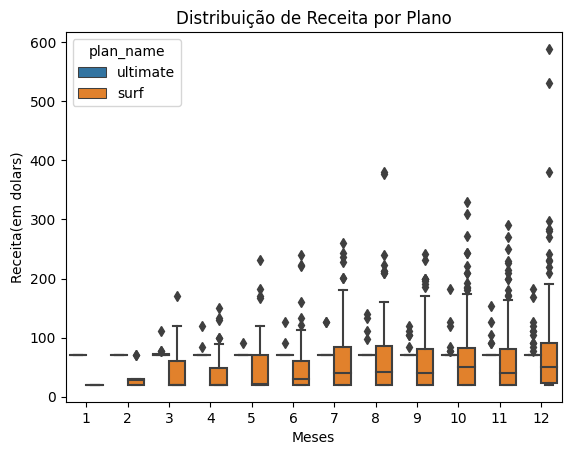

In [45]:
sns.boxplot(data=df_merged,hue='plan_name',x='month',y='receita')
plt.xlabel('Meses')
plt.ylabel("Receita(em dolars)")
plt.title('Distribuição de Receita por Plano')
plt.show()

- A média da receita do plano ultimate é maior que a  do surf.

## Teste hipóteses estatísticas

### Teste de hipótese ultimate-surf

- Hipótese nula = a receita média dos usuários dos planos Ultimate e Surf são iguais.
- Hipótese alternativa =  a receita média dos usuários dos planos Ultimate e Surf são diferentes.
- Valor alfa = 0.05

In [46]:
# Teste as hipóteses
sample_1 = df_merged[df_merged['plan_name']=='ultimate']['receita']
sample_2 = df_merged[df_merged['plan_name']=='surf']['receita']
sample_1.var(),sample_2.var()

(129.8484855509195, 3054.0975059318425)

In [47]:
alpha= 0.05

result = st.ttest_ind(sample_1,sample_2,equal_var=False)
print('valor-p:',result.pvalue)

if result.pvalue < alpha:
    print('Rejeitamos a hipotese nula')
else:
    print('Não podemos rejeitar a hipotese nula')

valor-p: 3.6278039040985444e-16
Rejeitamos a hipotese nula


### Teste de hipótese NY-NJ

- Hipótese nula = a receita média dos usuários de NY-NJ são iguais e outras regiões são iguais.
- Hipótese alternativa =  a receita média dos usuários de NY-NJ são diferentes de outras regiões.
- Valor alfa = 0.05

In [48]:
# Teste as hipóteses
ny = df_merged[df_merged['city']=='New York-Newark-Jersey City, NY-NJ-PA MSA']['receita']
others = df_merged[df_merged['city']!='New York-Newark-Jersey City, NY-NJ-PA MSA']['receita']
ny.var(),others.var()

(1890.3234829081778, 2216.9641084823143)

In [49]:
ny.median(),others.median()

(51.080000000000005, 70.0)

In [50]:
results = st.ttest_ind(ny,others,equal_var=False)
print('Valor-p:',results.pvalue)

if results.pvalue < alpha:
    print('Rejeitamos a hipotese nula')
else:
    print('Não podemos rejeitar a hipotese nula')

Valor-p: 0.031237788444585222
Rejeitamos a hipotese nula


## Conclusão geral

#### Qual plano gera mais receita?
- Com base nas analises chegamos a conclusão de que o plano Surf tem mais usuarios, porem o plano ultimate gera mais receita por cliente. Se o objetivo for maximizar a receita, investir mais na campanha do ultimate pode ser a melhor escolha.

#### Usuários de NY-NJ geram uma receita média diferente?
- Vemos também que há uma diferença estatisticamente significativa na receita média dos clientes de NY-NJ em relação às demais regiões, e eles tendem a gerar menos receita.